# La Liga Match Outcome Prediction — D1 & D2
**Course:** Intelligent Systems  
**Dataset:** Football La Liga — Seasons 2005/06 onwards  
**Task:** Multi-class Classification — predict the Full-Time Result (Home Win / Draw / Away Win)  

---
## Table of Contents
1. [D1 — Know Your Data](#d1)
   - 1.1 Dataset Description
   - 1.2 Exploratory Data Analysis (EDA)
   - 1.3 Visualizations
2. [D2 — Tabular Data Project](#d2)
   - 2.1 Data Cleaning & Feature Engineering
   - 2.2 Encoding & Normalization
   - 2.3 PCA (Dimensionality Reduction)
   - 2.4 Train / Validation / Test Split (Stratified K-Fold)
   - 2.5 Model Training & Experiments
   - 2.6 Metrics, Confusion Matrices & Plots
   - 2.7 Feature Importance
   - 2.8 Final Model & Conclusions
   - 2.9 Comparison with Literature

---
<a id='d1'></a>
# D1 — Know Your Data

## 1.1 Dataset Description

The dataset contains historical match data from **La Liga** (Spanish top football division), covering seasons from **2005/06** onwards.  
Each row represents a single match and includes:

| Column | Meaning |
|--------|----------|
| `Date` | Match date |
| `HomeTeam` / `AwayTeam` | Team names |
| `FTHG` / `FTAG` | Full-Time Home/Away Goals |
| `FTR` | **Full-Time Result** — target variable: H, D, A |
| `HTHG` / `HTAG` | Half-Time Home/Away Goals |
| `HTR` | Half-Time Result — H, D, A |
| `HS` / `AS` | Home/Away Shots |
| `HST` / `AST` | Home/Away Shots on Target |
| `HF` / `AF` | Home/Away Fouls |
| `HC` / `AC` | Home/Away Corners |
| `HY` / `AY` | Home/Away Yellow Cards |
| `HR` / `AR` | Home/Away Red Cards |
| `Referee` | Referee name (entirely missing — will be dropped) |
| `Sursă.Nume` | Source file name (metadata — will be dropped) |

**Task type:** Multi-class Classification (3 classes: H, D, A)  
**Total samples:** 7600 matches

In [4]:
# ── Imports ─────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# XGBoost & CatBoost — install if missing:
#   pip install xgboost catboost
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Nicer plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1.2 Loading the Data

In [5]:
# Loading the Excel file and displaying basic information about the dataset
INPUT_FILE = 'Football_LaLiga_DataSets_From0506.xlsx'

df_raw = pd.read_excel(INPUT_FILE, sheet_name=0)
print(f'Shape: {df_raw.shape}')
df_raw.head(5)

Shape: (7600, 23)


,Sursă.Nume,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,season-0506.csv,2005-08-27,Alaves,Barcelona,0,0,D,0,0,D,...,0,10,17,19,3,7,0,1,0,0
1,season-0506.csv,2005-08-27,Ath Bilbao,Sociedad,3,0,H,0,0,D,...,6,2,13,19,3,4,0,1,0,0
2,season-0506.csv,2005-08-27,Valencia,Betis,1,0,H,0,0,D,...,2,3,18,14,8,5,2,3,0,0
3,season-0506.csv,2005-08-28,Ath Madrid,Zaragoza,0,0,D,0,0,D,...,5,2,16,22,8,4,2,7,0,0
4,season-0506.csv,2005-08-28,Cadiz,Real Madrid,1,2,A,0,1,A,...,5,6,19,25,8,8,2,2,0,0


In [6]:
# Basic info: dtypes and memory usage
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Sursă.Nume  7600 non-null   str           
 1   Date        7600 non-null   datetime64[us]
 2   HomeTeam    7600 non-null   str           
 3   AwayTeam    7600 non-null   str           
 4   FTHG        7600 non-null   int64         
 5   FTAG        7600 non-null   int64         
 6   FTR         7600 non-null   str           
 7   HTHG        7600 non-null   int64         
 8   HTAG        7600 non-null   int64         
 9   HTR         7600 non-null   str           
 10  Referee     0 non-null      float64       
 11  HS          7600 non-null   int64         
 12  AS          7600 non-null   int64         
 13  HST         7600 non-null   int64         
 14  AST         7600 non-null   int64         
 15  HF          7600 non-null   int64         
 16  AF          7600 non-null   int64  

In [7]:
# Summary statistics for numerical columns
df_raw.describe()

,Date,FTHG,FTAG,HTHG,HTAG,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
count,7600,7600.000000,7600.000000,7600.000000,7600.000000,0.0,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000
mean,2015-07-15 11:37:04.421052,1.530526,1.132237,0.681316,0.494737,NaN,13.667105,10.801974,4.880263,3.775789,14.697237,14.572763,5.681316,4.323026,2.406447,2.649737,0.133947,0.162237
min,2005-08-27 00:00:00,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2010-08-02 00:00:00,1.000000,0.000000,0.000000,0.000000,NaN,10.000000,8.000000,3.000000,2.000000,11.000000,11.000000,4.000000,2.000000,1.000000,2.000000,0.000000,0.000000
50%,2015-07-07 00:00:00,1.000000,1.000000,0.000000,0.000000,NaN,13.000000,10.000000,5.000000,3.000000,14.000000,14.000000,5.000000,4.000000,2.000000,3.000000,0.000000,0.000000
75%,2020-08-01 18:00:00,2.000000,2.000000,1.000000,1.000000,NaN,17.000000,14.000000,6.000000,5.000000,18.000000,18.000000,7.000000,6.000000,3.000000,4.000000,0.000000,0.000000
max,2025-05-25 00:00:00,10.000000,8.000000,6.000000,5.000000,NaN,40.000000,39.000000,20.000000,16.000000,37.000000,36.000000,26.000000,17.000000,9.000000,9.000000,3.000000,4.000000
std,NaN,1.312823,1.125971,0.851537,0.712325,NaN,5.053651,4.438982,2.605961,2.221927,4.759188,4.762690,2.956725,2.513655,1.491189,1.519518,0.369882,0.408645


## 1.3 Exploratory Data Analysis (EDA)

In [8]:
# ── Missing values ───────────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
Referee,7600,100.0


**Observation:** The `Referee` column is **100% missing** across all 7600 rows. It will be dropped entirely. `Sursă.Nume` is just a metadata column (source file name) and will also be dropped.

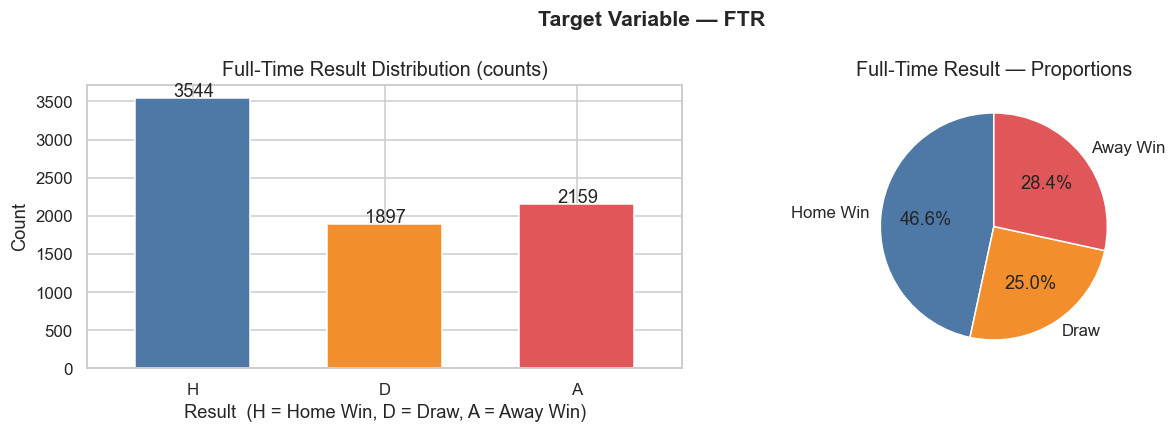

FTR
H    3544
D    1897
A    2159


In [11]:
# ── Target class distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ftr_counts = df_raw['FTR'].value_counts().reindex(['H', 'D', 'A'])

ftr_counts.plot(kind='bar', ax=axes[0], color=['#4e79a7', '#f28e2b', '#e15759'],
                edgecolor='white', width=0.6)
axes[0].set_title('Full-Time Result Distribution (counts)', fontsize=13)
axes[0].set_xlabel('Result  (H = Home Win, D = Draw, A = Away Win)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['H', 'D', 'A'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+0.20, p.get_height()+20))

axes[1].pie(ftr_counts, labels=['Home Win', 'Draw', 'Away Win'],
            autopct='%1.1f%%', colors=['#4e79a7', '#f28e2b', '#e15759'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Full-Time Result — Proportions', fontsize=13)

plt.suptitle('Target Variable — FTR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(ftr_counts.to_string())

**Observation:** Home wins are the most frequent outcome (~47%), followed by Away wins (~28%) and Draws (~25%). The dataset is **moderately imbalanced** — we must use stratified splits and weighted metrics.

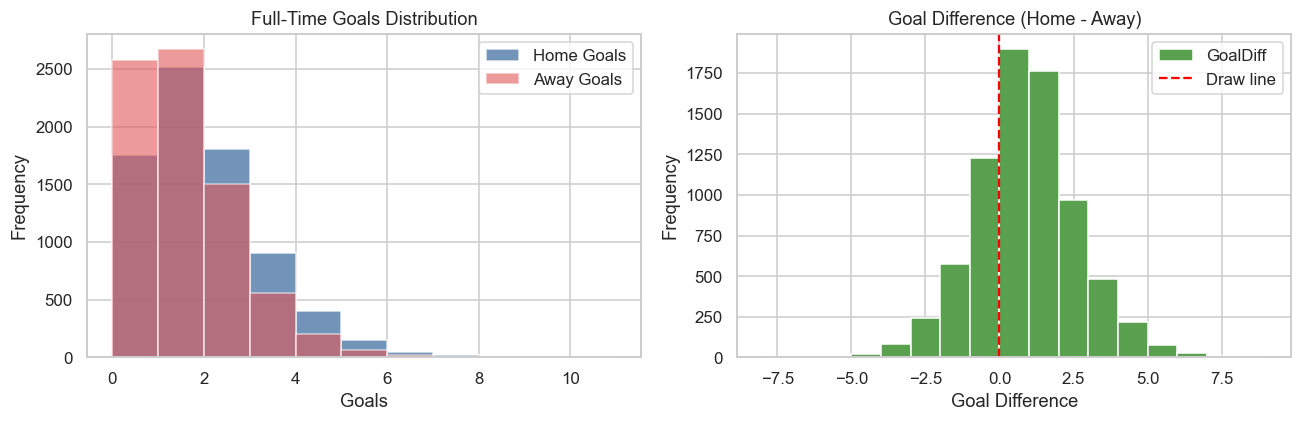

Mean home goals: 1.53
Mean away goals: 1.13


In [12]:
# ── Goals distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['FTHG'], bins=range(0, 12), color='#4e79a7', alpha=0.8,
             edgecolor='white', label='Home Goals')
axes[0].hist(df_raw['FTAG'], bins=range(0, 12), color='#e15759', alpha=0.6,
             edgecolor='white', label='Away Goals')
axes[0].set_title('Full-Time Goals Distribution')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Goal difference
df_raw['GoalDiff'] = df_raw['FTHG'] - df_raw['FTAG']
df_raw['GoalDiff'].plot(kind='hist', bins=range(-8, 10), ax=axes[1],
                        color='#59a14f', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Draw line')
axes[1].set_title('Goal Difference (Home - Away)')
axes[1].set_xlabel('Goal Difference')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean home goals: {df_raw['FTHG'].mean():.2f}")
print(f"Mean away goals: {df_raw['FTAG'].mean():.2f}")

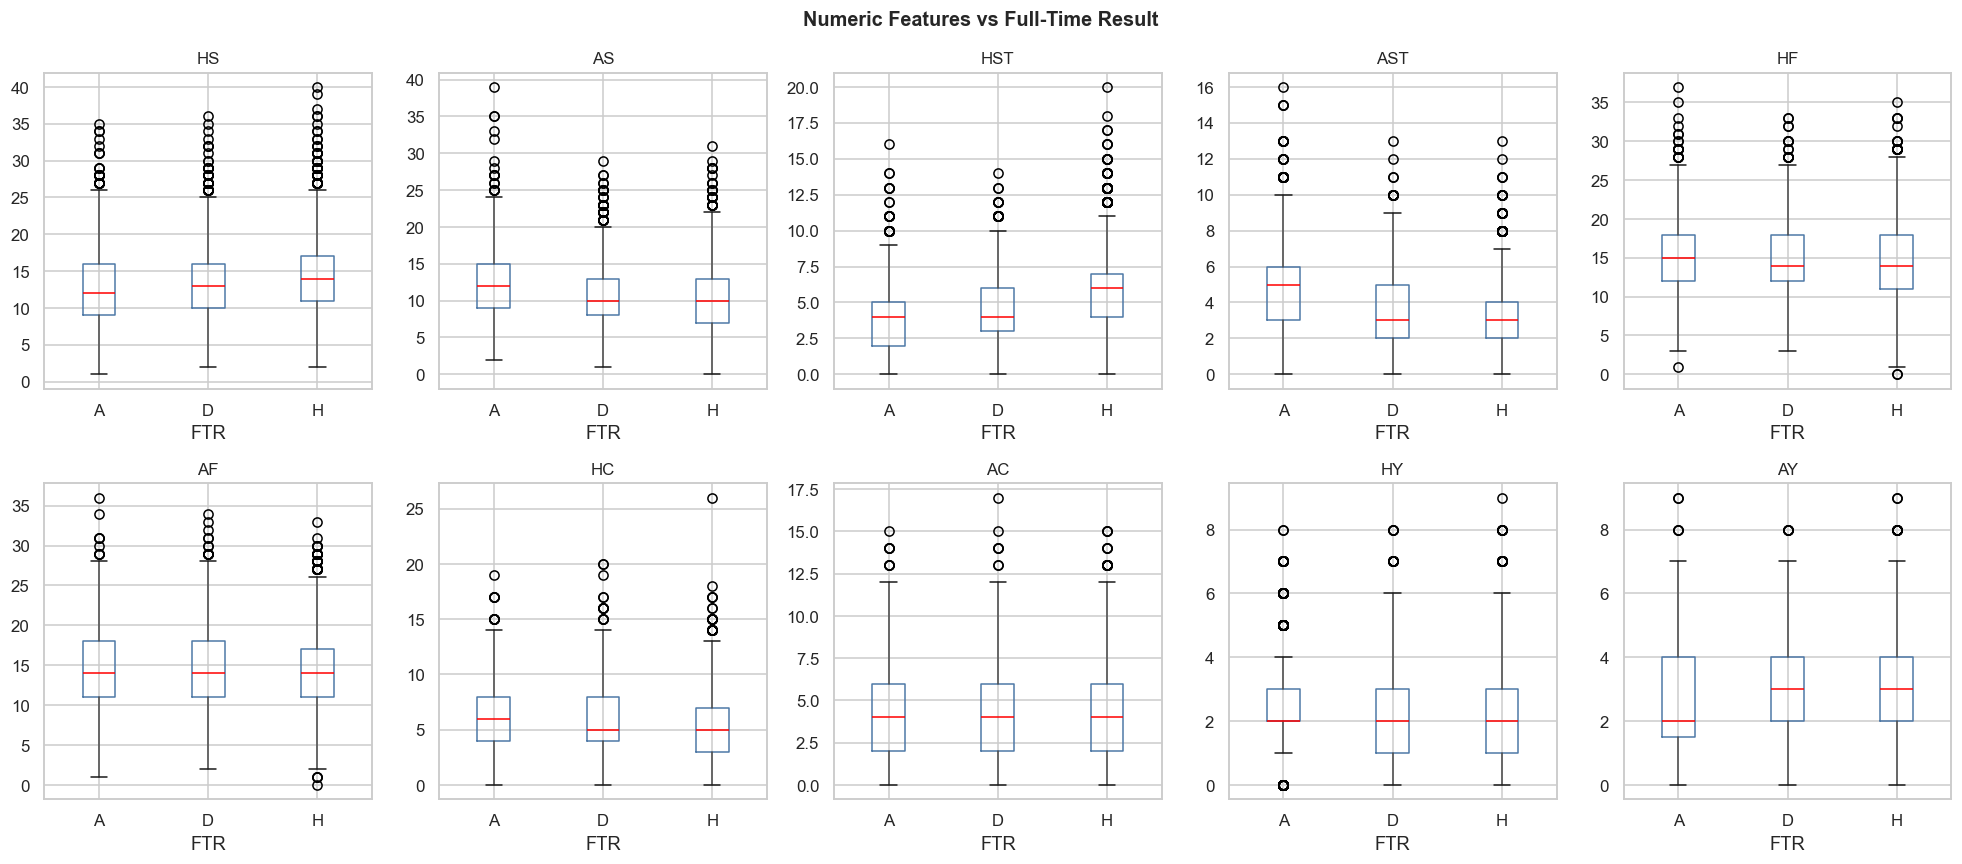

In [13]:
# ── Numeric feature distributions (boxplots by FTR) ─────────────────────────
numeric_features = ['HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    df_raw.boxplot(column=col, by='FTR', ax=axes[i],
                   boxprops=dict(color='#4e79a7'),
                   medianprops=dict(color='red'))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('FTR')
    axes[i].set_ylabel('')

plt.suptitle('Numeric Features vs Full-Time Result', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

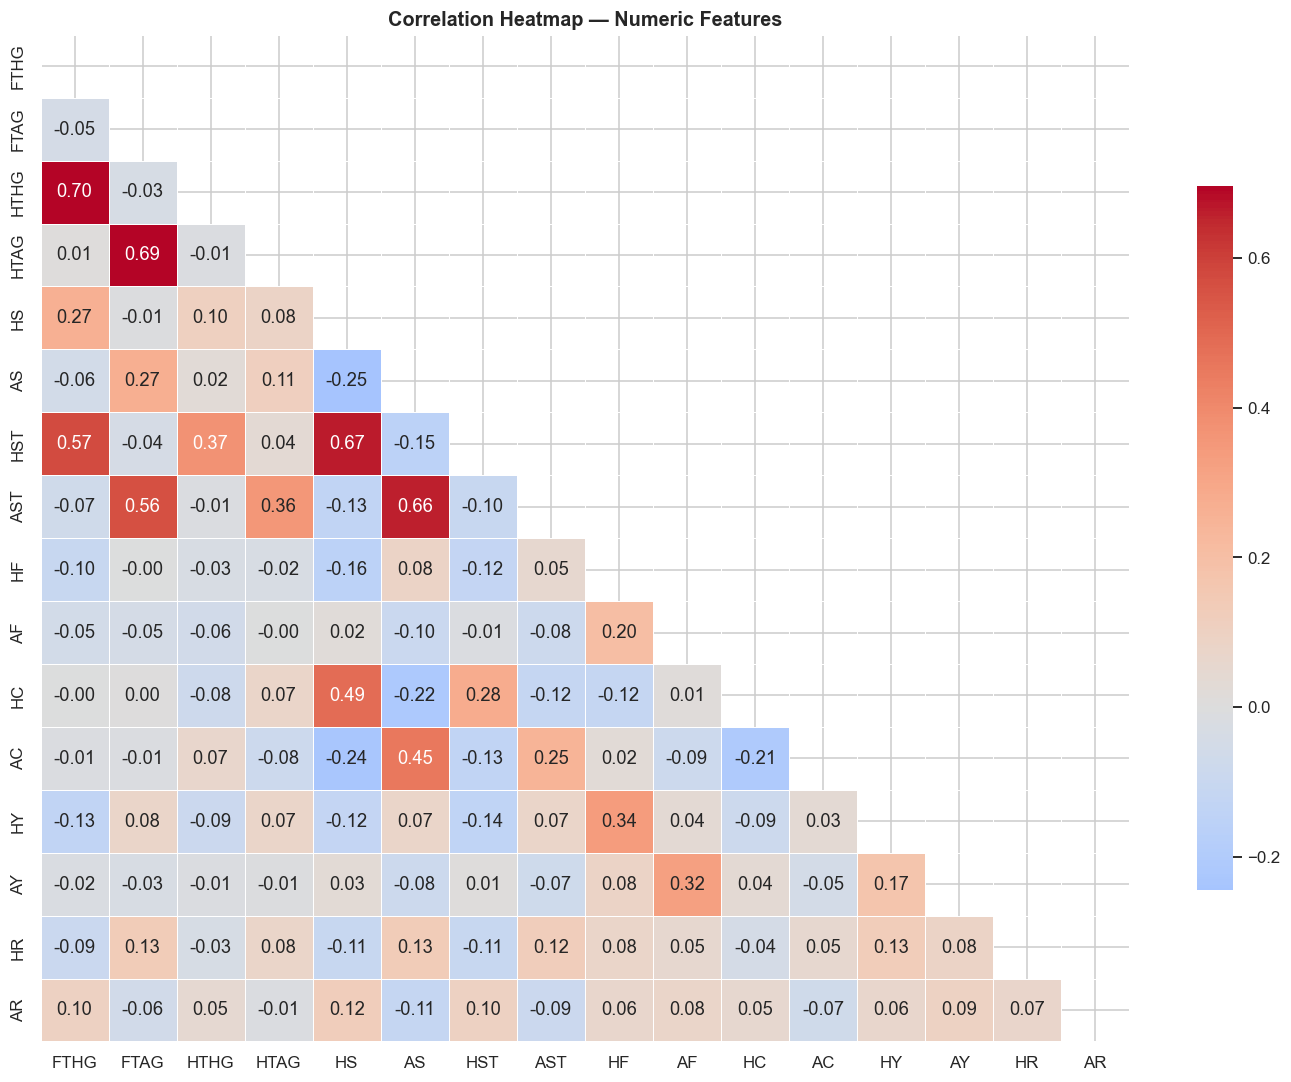

In [14]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
num_cols = ['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST',
            'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']

corr = df_raw[num_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, cbar_kws={'shrink': 0.7})
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Key observations from correlations:**
- `FTHG` (Full-Time Home Goals) is strongly correlated with `HST` (Home Shots on Target) — makes intuitive sense.
- `FTAG` correlates strongly with `AST`.
- `HS` and `HST` are correlated (~0.7) — but we keep both since shots on target is more informative.
- Fouls / cards show moderate negative correlation with goal variables.

Half-Time Result vs Full-Time Result:
 FTR     A     D     H
HTR                  
A    1191   337   199
D     831  1184  1244
H     137   376  2101


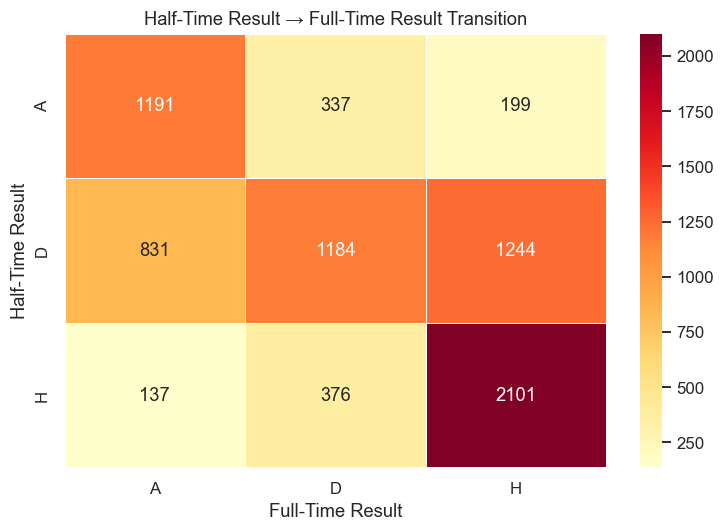

In [15]:
# ── Half-time result vs full-time result (confusion-style count plot) ─────────
ht_ft = pd.crosstab(df_raw['HTR'], df_raw['FTR'])
print('Half-Time Result vs Full-Time Result:\n', ht_ft)

plt.figure(figsize=(7, 5))
sns.heatmap(ht_ft, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Half-Time Result → Full-Time Result Transition', fontsize=12)
plt.xlabel('Full-Time Result')
plt.ylabel('Half-Time Result')
plt.tight_layout()
plt.show()

**Observation:** There is a strong persistence effect — a team leading at half-time is very likely to win the match. This makes `HTR` a highly predictive feature.

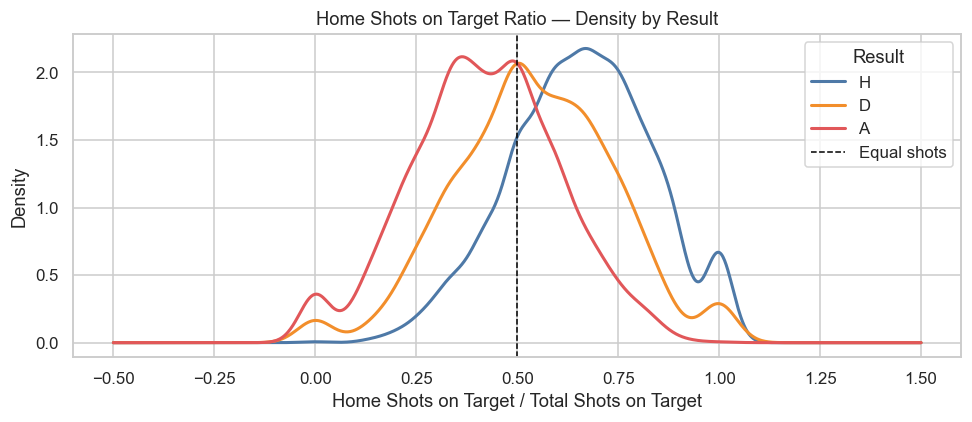

In [16]:
# ── Shots on Target ratio distribution by result ──────────────────────────────
df_raw['ShotRatio'] = df_raw['HST'] / (df_raw['HST'] + df_raw['AST'] + 1e-6)

plt.figure(figsize=(9, 4))
for label, color in zip(['H', 'D', 'A'], ['#4e79a7', '#f28e2b', '#e15759']):
    subset = df_raw[df_raw['FTR'] == label]['ShotRatio']
    subset.plot(kind='density', label=label, color=color, linewidth=2)

plt.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Equal shots')
plt.title('Home Shots on Target Ratio — Density by Result', fontsize=12)
plt.xlabel('Home Shots on Target / Total Shots on Target')
plt.legend(title='Result')
plt.tight_layout()
plt.show()

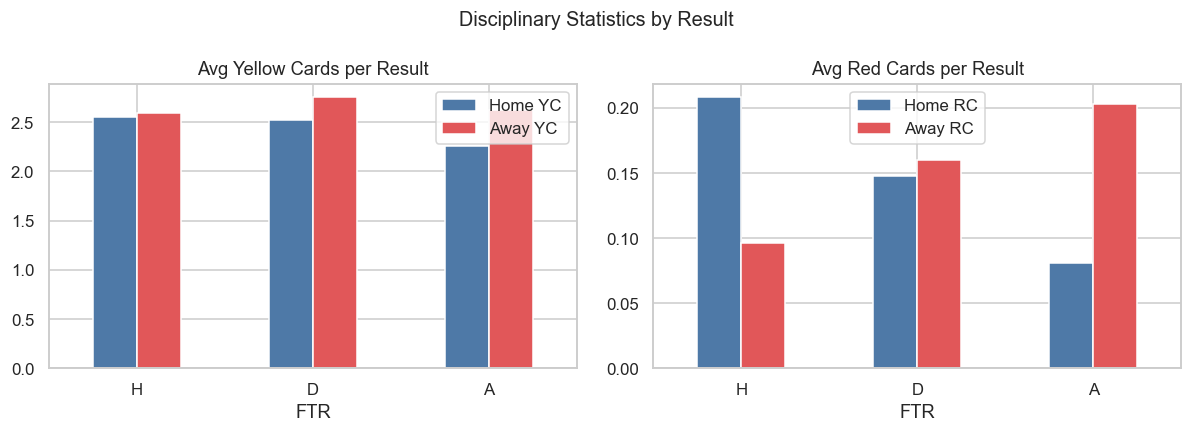

In [17]:
# ── Yellow cards distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df_raw.groupby('FTR')[['HY', 'AY']].mean().plot(kind='bar', ax=axes[0],
    color=['#4e79a7', '#e15759'], edgecolor='white')
axes[0].set_title('Avg Yellow Cards per Result')
axes[0].set_xticklabels(['H', 'D', 'A'], rotation=0)
axes[0].legend(['Home YC', 'Away YC'])

df_raw.groupby('FTR')[['HR', 'AR']].mean().plot(kind='bar', ax=axes[1],
    color=['#4e79a7', '#e15759'], edgecolor='white')
axes[1].set_title('Avg Red Cards per Result')
axes[1].set_xticklabels(['H', 'D', 'A'], rotation=0)
axes[1].legend(['Home RC', 'Away RC'])

plt.suptitle('Disciplinary Statistics by Result', fontsize=13)
plt.tight_layout()
plt.show()

---
<a id='d2'></a>
# D2 — Tabular Data Project

## 2.1 Data Cleaning & Feature Engineering

**Design decisions:**
1. Drop `Referee` (100% missing) and `Sursă.Nume` (metadata).
2. Drop `Date`, `HomeTeam`, `AwayTeam` — raw text identifiers that would require complex encoding and could cause data leakage. Team strength is implicitly captured by shot/goal statistics.
3. Drop `FTHG` and `FTAG` — they *directly determine* FTR (they would be unavailable at prediction time anyway). We keep half-time stats because they are known at HT, before FT.
4. Engineer new features that are domain-meaningful and leak-free.
5. Encode `HTR` (Half-Time Result) using One-Hot Encoding.

In [18]:
# Work on a copy
df = df_raw.copy()

# ── Drop leaky / metadata columns ───────────────────────────────────────────
# FTHG / FTAG are dropped: knowing full-time goals means knowing the result
COLS_TO_DROP = ['Sursă.Nume', 'Date', 'HomeTeam', 'AwayTeam',
                'Referee', 'FTHG', 'FTAG', 'GoalDiff', 'ShotRatio']
df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns], inplace=True)

print('Remaining columns:', df.columns.tolist())

Remaining columns: ['FTR', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']


In [20]:
# ── Feature engineering ──────────────────────────────────────────────────────
# Difference features capture the relative advantage of one team over the other.
# These are more informative than raw counts in isolation.

df['ShotDiff']    = df['HS']  - df['AS']   # Shots advantage for Home team
df['ShotOnTDiff'] = df['HST'] - df['AST']  # Shots on target advantage
df['FoulDiff']    = df['HF']  - df['AF']   # Foul difference
df['CornerDiff']  = df['HC']  - df['AC']   # Corner advantage
df['YellowDiff']  = df['HY']  - df['AY']   # Yellow card difference
df['RedDiff']     = df['HR']  - df['AR']   # Red card difference

# Half-time goal difference — strong predictor
df['HTGoalDiff']  = df['HTHG'] - df['HTAG']

# Shot accuracy (shots on target / total shots) — avoid div-by-zero
df['HShotAcc'] = df['HST'] / (df['HS'] + 1e-6)
df['AShotAcc'] = df['AST'] / (df['AS'] + 1e-6)

print(f'Dataset shape after engineering: {df.shape}')
df.head(3)

Dataset shape after engineering: (7600, 25)


,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HF,AF,...,AR,ShotDiff,ShotOnTDiff,FoulDiff,CornerDiff,YellowDiff,RedDiff,HTGoalDiff,HShotAcc,AShotAcc
0,D,0,0,D,5,17,0,10,17,19,...,0,-12,-10,-2,-4,-1,0,0,0.000000,0.588235
1,H,0,0,D,10,9,6,2,13,19,...,0,1,4,-6,-1,-1,0,0,0.600000,0.222222
2,H,0,0,D,9,14,2,3,18,14,...,0,-5,-1,4,3,-1,0,0,0.222222,0.214286


## 2.2 Encoding & Normalization

- `HTR` (categorical: H/D/A) → **One-Hot Encoding** (OHE)  
- `FTR` (target: H/D/A) → **Label Encoding** (0=A, 1=D, 2=H for sklearn)  
- Numerical features → **StandardScaler** (zero mean, unit variance) — required for SVM and PCA.

In [21]:
# ── One-Hot Encode HTR ───────────────────────────────────────────────────────
df = pd.get_dummies(df, columns=['HTR'], prefix='HTR')

# ── Label Encode FTR (target) ────────────────────────────────────────────────
le = LabelEncoder()
df['FTR_encoded'] = le.fit_transform(df['FTR'])   # A=0, D=1, H=2
print('FTR classes:', list(zip(le.classes_, le.transform(le.classes_))))

# Separate features and target
y = df['FTR_encoded'].values
X = df.drop(columns=['FTR', 'FTR_encoded'])

print(f'X shape: {X.shape}, y shape: {y.shape}')
X.head(3)

FTR classes: [('A', np.int64(0)), ('D', np.int64(1)), ('H', np.int64(2))]
X shape: (7600, 26), y shape: (7600,)


,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,...,FoulDiff,CornerDiff,YellowDiff,RedDiff,HTGoalDiff,HShotAcc,AShotAcc,HTR_A,HTR_D,HTR_H
0,0,0,5,17,0,10,17,19,3,7,...,-2,-4,-1,0,0,0.000000,0.588235,False,True,False
1,0,0,10,9,6,2,13,19,3,4,...,-6,-1,-1,0,0,0.600000,0.222222,False,True,False
2,0,0,9,14,2,3,18,14,8,5,...,4,3,-1,0,0,0.222222,0.214286,False,True,False


In [25]:
# ── Standardize features ─────────────────────────────────────────────────────
# Note: scaler is fit ONLY on training data in the cross-validation loop to avoid
# data leakage. Here we create a scaled version for PCA visualization only.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check that scaling worked (mean ~0, std ~1 for first few features)
print('Mean of first 5 features (should be ~0):', X_scaled[:, :5].mean(axis=0).round(4))
print('Std  of first 5 features (should be ~1):', X_scaled[:, :5].std(axis=0).round(4))

Mean of first 5 features (should be ~0): [-0.  0. -0. -0.  0.]
Std  of first 5 features (should be ~1): [1. 1. 1. 1. 1.]


## 2.3 PCA — Dimensionality Reduction & Visualization

PCA (Principal Component Analysis) transforms the feature space into orthogonal components ordered by explained variance. It is useful for:
- Visualizing high-dimensional data in 2D/3D.
- Reducing features while preserving variance (less overfitting, faster training).

Mathematically, PCA finds directions `z1, z2, ...` in feature space that maximize variance. These are the **eigenvectors** of the covariance matrix.

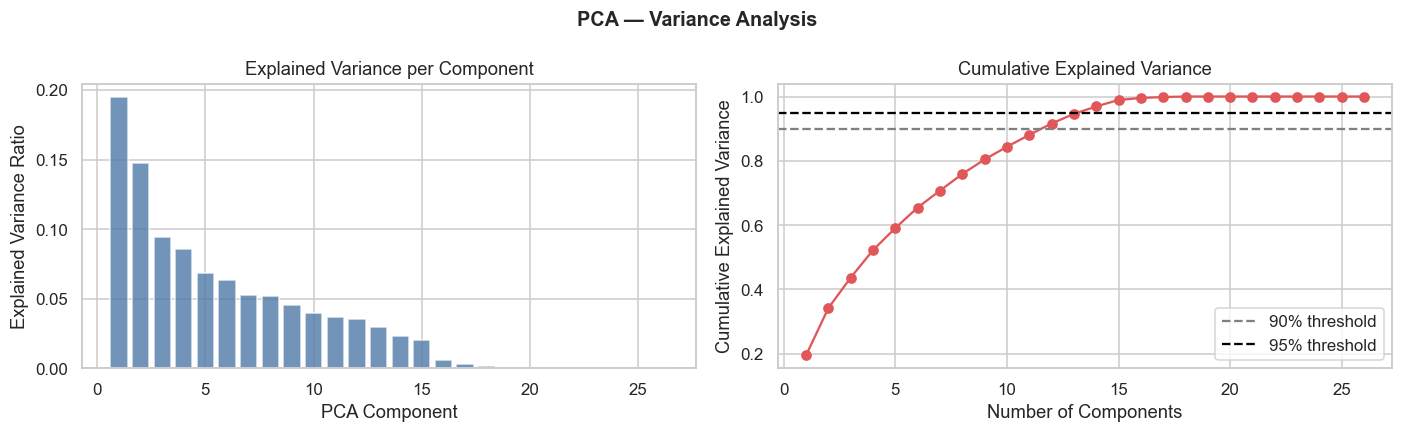

Components to explain 90% variance: 12
Components to explain 95% variance: 14


In [26]:
# ── Fit full PCA to see explained variance per component ────────────────────
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(explained)+1), explained, color='#4e79a7', alpha=0.8)
axes[0].set_title('Explained Variance per Component')
axes[0].set_xlabel('PCA Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(range(1, len(cumulative)+1), cumulative, marker='o', color='#e15759')
axes[1].axhline(0.90, color='gray', linestyle='--', label='90% threshold')
axes[1].axhline(0.95, color='black', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].legend()

plt.suptitle('PCA — Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

n_90 = np.argmax(cumulative >= 0.90) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1
print(f'Components to explain 90% variance: {n_90}')
print(f'Components to explain 95% variance: {n_95}')

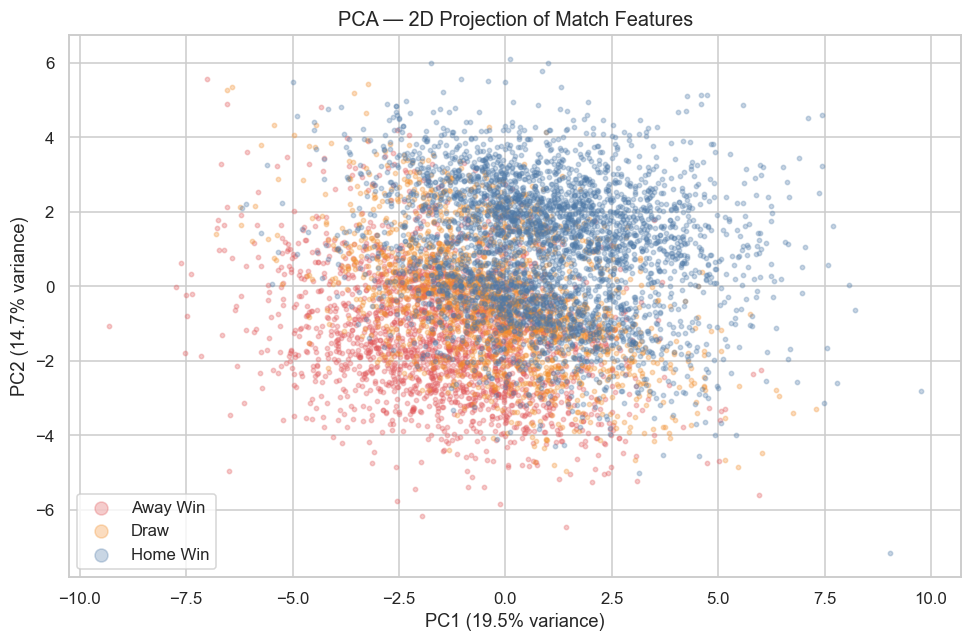

In [28]:
# ── 2D PCA scatter — for visualization only ──────────────────────────────────
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca2 = pca_2d.fit_transform(X_scaled)

label_names = {0: 'Away Win', 1: 'Draw', 2: 'Home Win'}
colors = {0: '#e15759', 1: '#f28e2b', 2: '#4e79a7'}

plt.figure(figsize=(9, 6))
for label in [0, 1, 2]:
    mask = y == label
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                label=label_names[label], color=colors[label],
                alpha=0.3, s=8)

plt.title('PCA — 2D Projection of Match Features', fontsize=13)
plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

**Observation:** The three classes partially overlap in 2D PCA space — this confirms that the problem is non-trivial and linear boundaries alone will not be sufficient. Non-linear models (RF, XGBoost, CatBoost) should perform better.

## 2.4 Train / Validation / Test Split

**Strategy:**
- Hold out **15%** as a fixed test set (used ONLY for final evaluation).
- Use **Stratified 5-Fold Cross-Validation** on the remaining 85% for hyperparameter tuning and model comparison.
- Stratification ensures each fold has the same class proportions as the full dataset (important given the class imbalance).

This matches the lecture recommendation: train+val NOT fixed, K-Fold CV, test only at the end.

In [29]:
from sklearn.model_selection import train_test_split

# ── Hold-out test set (15%) ──────────────────────────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=SEED, stratify=y
)

print(f'Train+Val: {X_trainval.shape[0]} samples')
print(f'Test:      {X_test.shape[0]} samples')

# Verify stratification
print('\nClass distribution in Train+Val:', np.bincount(y_trainval))
print('Class distribution in Test:      ', np.bincount(y_test))

# ── Stratified 5-Fold CV setup ───────────────────────────────────────────────
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Train+Val: 6460 samples
Test:      1140 samples

Class distribution in Train+Val: [1835 1613 3012]
Class distribution in Test:       [324 284 532]


## 2.5 Model Training & Experiments

We experiment with **5 classifiers**:

| Model | Reason for inclusion |
|-------|---------------------|
| Decision Tree (DT) | Simple baseline; interpretable |
| Random Forest (RF) | Ensemble of DTs; handles non-linearity well |
| SVM | Strong for structured tabular data with proper scaling |
| XGBoost | Gradient boosting; state-of-the-art on tabular data |
| CatBoost | Gradient boosting; handles features natively, few hyperparams to tune |

Evaluation metric: **weighted F1-score** (accounts for class imbalance).

In [33]:
# ── Define models ────────────────────────────────────────────────────────────
models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=20, random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=10,
        n_jobs=-1, random_state=SEED
    ),
    'SVM': SVC(
        # Note: SVM can be sensitive to feature scaling, which is why we standardize features before training.
        # RBF - Radial Basis Function kernel captures non-linear relationships
        kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovo',
        random_state=SEED
    ),
    'XGBoost': XGBClassifier(
        # subsample uses 80% of data for each tree randomly
        # colsample_bytree uses 80% of features randomly => helps prevent overfitting
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss',
        n_jobs=-1, random_state=SEED
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        loss_function='MultiClass', verbose=False,
        random_state=SEED
    ),
}

print('Models initialized:', list(models.keys()))

Models initialized: ['Decision Tree', 'Random Forest', 'SVM', 'XGBoost', 'CatBoost']


In [35]:
# ── Stratified K-Fold Cross-Validation ───────────────────────────────────────
# This cell trains 5 folds × 5 models = 25 training runs.
# CatBoost / XGBoost with 300 estimators may take 1-3 minutes total.
# No GPU required — all models run on CPU.

cv_results = {}   # {model_name: array of fold F1 scores}
# F1 scores = 2 * (precision * recall) / (precision + recall) — harmonic mean of precision and recall

for name, model in models.items():
    scores = cross_val_score(
        model, X_trainval, y_trainval,
        cv=SKF, scoring='f1_weighted', n_jobs=1
    )
    cv_results[name] = scores
    print(f'{name:20s}  F1 per fold: {np.round(scores, 4)}  '
          f'Mean: {scores.mean():.4f} ± {scores.std():.4f}')

Decision Tree         F1 per fold: [0.6204 0.6201 0.6154 0.6358 0.6111]  Mean: 0.6206 ± 0.0084
Random Forest         F1 per fold: [0.6532 0.6534 0.6287 0.6457 0.6563]  Mean: 0.6475 ± 0.0100
SVM                   F1 per fold: [0.6499 0.6591 0.643  0.6528 0.6548]  Mean: 0.6519 ± 0.0054
XGBoost               F1 per fold: [0.6618 0.6536 0.6383 0.645  0.6458]  Mean: 0.6489 ± 0.0081
CatBoost              F1 per fold: [0.653  0.6538 0.6367 0.6465 0.6594]  Mean: 0.6499 ± 0.0078


In [36]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    name: {
        'Mean F1 (CV)': scores.mean(),
        'Std F1 (CV)':  scores.std(),
        'Min F1':       scores.min(),
        'Max F1':       scores.max(),
    }
    for name, scores in cv_results.items()
}).T.round(4)

summary.sort_values('Mean F1 (CV)', ascending=False)

,Mean F1 (CV),Std F1 (CV),Min F1,Max F1
SVM,0.6519,0.0054,0.6430,0.6591
CatBoost,0.6499,0.0078,0.6367,0.6594
XGBoost,0.6489,0.0081,0.6383,0.6618
Random Forest,0.6475,0.0100,0.6287,0.6563
Decision Tree,0.6206,0.0084,0.6111,0.6358


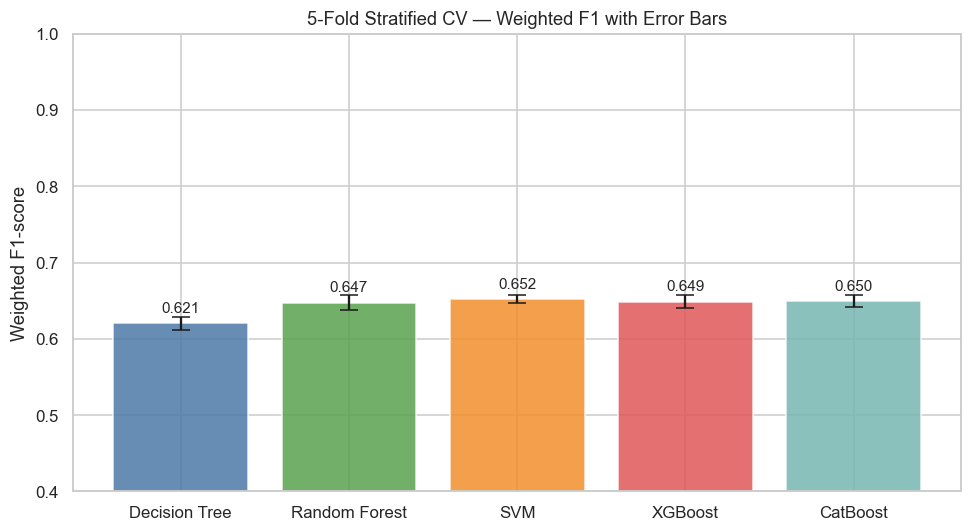

In [38]:
# ── Plot CV results with error bars ──────────────────────────────────────────
means  = [cv_results[n].mean() for n in models]
stds   = [cv_results[n].std()  for n in models]
names  = list(models.keys())

fig, ax = plt.subplots(figsize=(9, 5))
# yerr=stds adds error bars representing the variability across folds
bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=['#4e79a7', '#59a14f', '#f28e2b', '#e15759', '#76b7b2'],
              alpha=0.85, edgecolor='white')
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Weighted F1-score')
ax.set_title('5-Fold Stratified CV — Weighted F1 with Error Bars', fontsize=12)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 2.6 Metrics, Confusion Matrices & Plots

We now train each model on the **full train+val set** and evaluate on the **held-out test set** (used only once).

In [39]:
# ── Final evaluation on held-out test set ────────────────────────────────────
test_results = {}
class_names  = le.classes_   # ['A', 'D', 'H']

for name, model in models.items():
    model.fit(X_trainval, y_trainval)
    y_pred = model.predict(X_test)

    test_results[name] = {
        'y_pred':    y_pred,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall':    recall_score(y_test, y_pred, average='weighted'),
        'f1':        f1_score(y_test, y_pred, average='weighted'),
    }

# ── Print classification reports ─────────────────────────────────────────────
for name, res in test_results.items():
    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(y_test, res['y_pred'],
                                 target_names=class_names))


  Decision Tree
              precision    recall  f1-score   support

           A       0.65      0.63      0.64       324
           D       0.37      0.34      0.35       284
           H       0.71      0.75      0.73       532

    accuracy                           0.61      1140
   macro avg       0.58      0.57      0.57      1140
weighted avg       0.61      0.61      0.61      1140


  Random Forest
              precision    recall  f1-score   support

           A       0.64      0.68      0.66       324
           D       0.38      0.26      0.31       284
           H       0.70      0.80      0.75       532

    accuracy                           0.63      1140
   macro avg       0.58      0.58      0.57      1140
weighted avg       0.61      0.63      0.61      1140


  SVM
              precision    recall  f1-score   support

           A       0.65      0.67      0.66       324
           D       0.40      0.29      0.33       284
           H       0.71      0.80 

In [40]:
# ── Metrics comparison table ─────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  res['accuracy'],
        'Precision': res['precision'],
        'Recall':    res['recall'],
        'F1 (weighted)': res['f1'],
    }
    for name, res in test_results.items()
}).T.round(4)

metrics_df.sort_values('F1 (weighted)', ascending=False)

,Accuracy,Precision,Recall,F1 (weighted)
XGBoost,0.6412,0.6240,0.6412,0.6302
CatBoost,0.6377,0.6204,0.6377,0.6266
SVM,0.6351,0.6138,0.6351,0.6207
Random Forest,0.6316,0.6064,0.6316,0.6143
Decision Tree,0.6140,0.6073,0.6140,0.6102


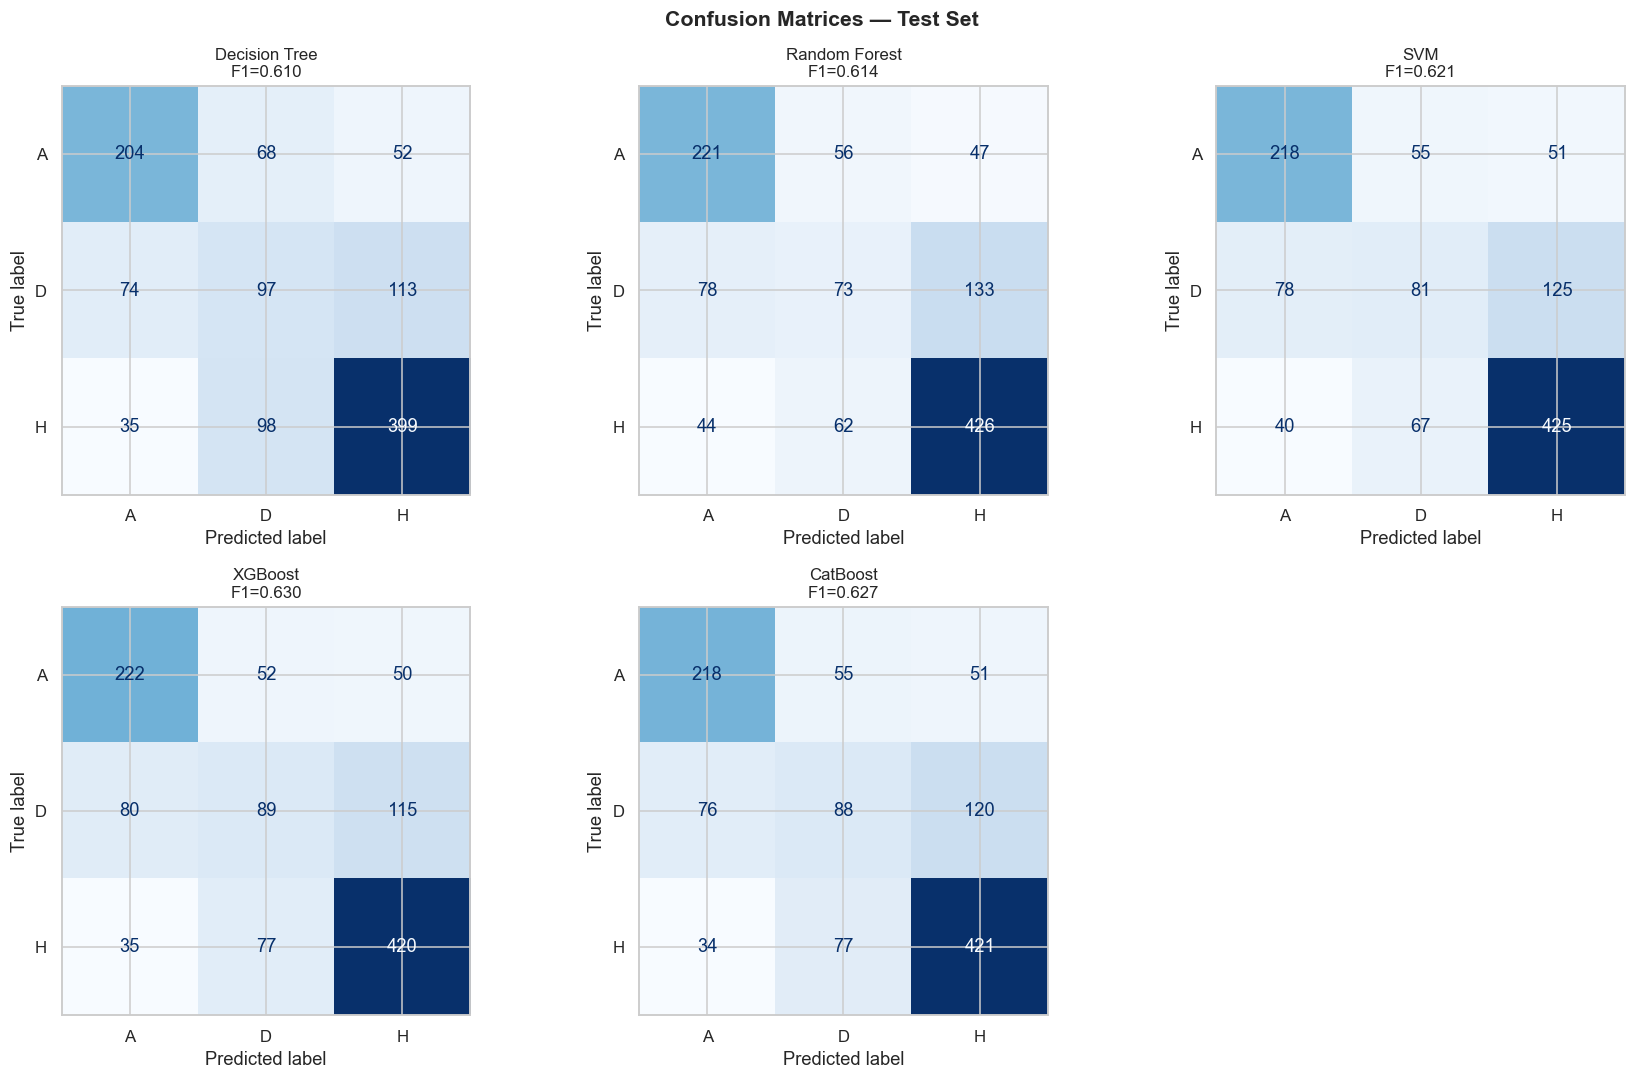

In [41]:
# ── Confusion matrices for all models ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nF1={res["f1"]:.3f}', fontsize=11)

# Hide the extra subplot
axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.7 Feature Importance

Tree-based models (Random Forest, XGBoost, CatBoost) provide built-in feature importances based on how much each feature reduces impurity across all splits.

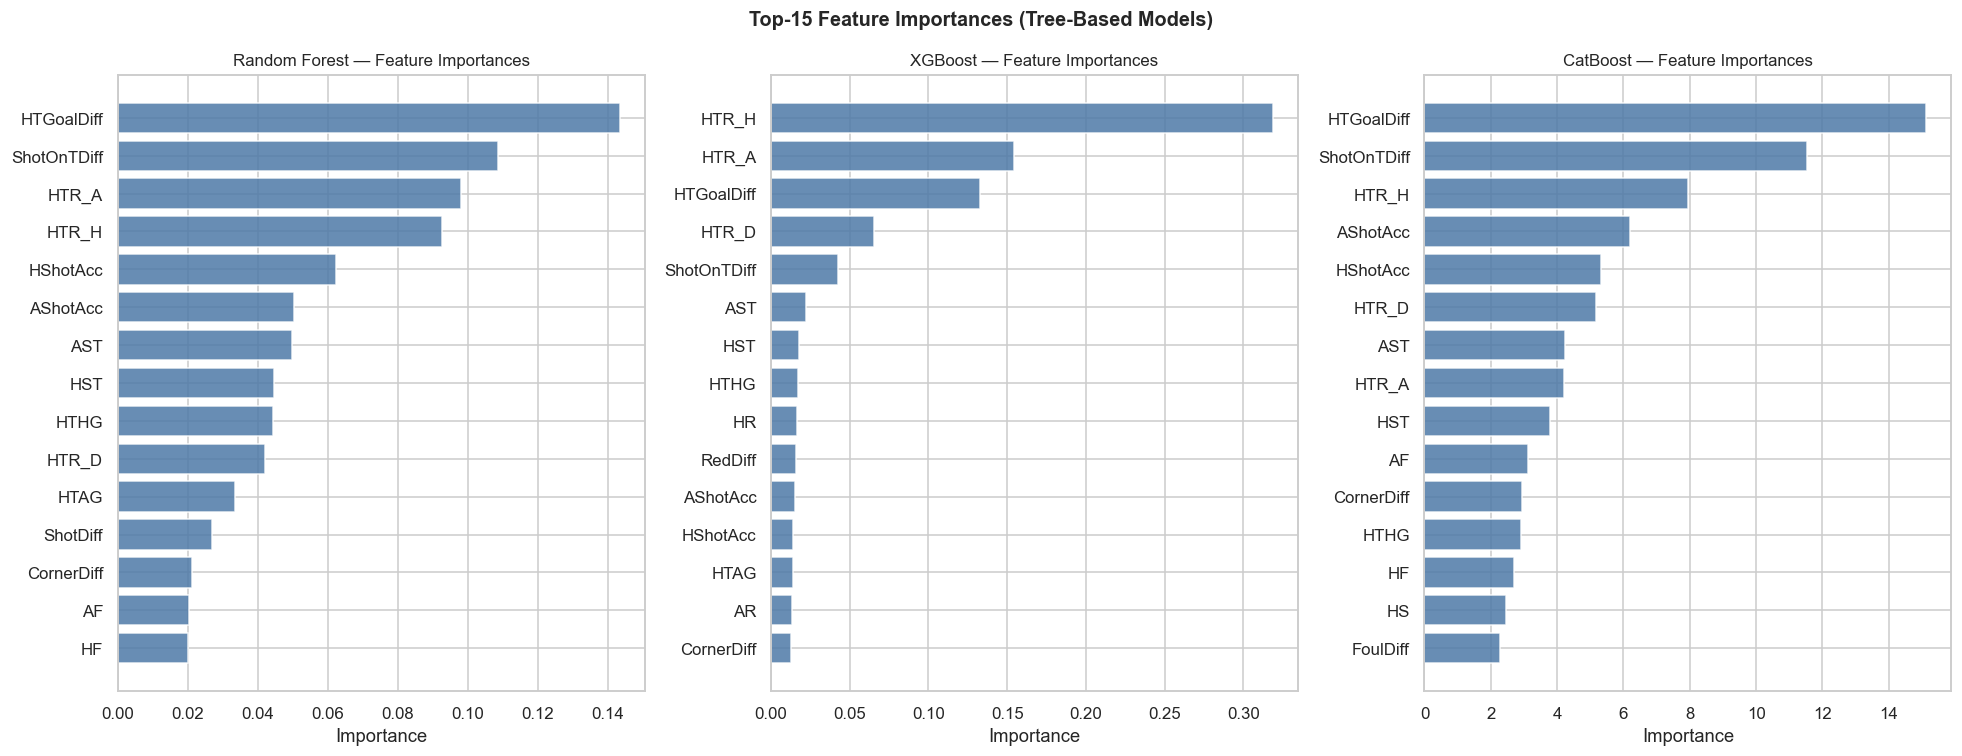

In [ ]:
feature_names = list(X.columns)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost', 'CatBoost']):
    model = models[model_name]
    importance = model.feature_importances_

    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    imp_df = imp_df.sort_values('Importance', ascending=True).tail(15)

    ax.barh(imp_df['Feature'], imp_df['Importance'], color='#4e79a7', alpha=0.85)
    ax.set_title(f'{model_name} — Feature Importances', fontsize=11)
    ax.set_xlabel('Importance')

plt.suptitle('Top-15 Feature Importances (Tree-Based Models)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.8 Final Model Selection & Conclusions

Based on cross-validation F1 scores and test-set performance, we select the best model and do one final evaluation.

In [43]:
# ── Select best model by CV F1 ───────────────────────────────────────────────
best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
best_model      = models[best_model_name]

print(f'Best model (by CV F1): {best_model_name}')
print(f'  CV  F1: {cv_results[best_model_name].mean():.4f} ± {cv_results[best_model_name].std():.4f}')
print(f'  Test F1: {test_results[best_model_name]["f1"]:.4f}')
print(f'  Test Acc: {test_results[best_model_name]["accuracy"]:.4f}')

Best model (by CV F1): SVM
  CV  F1: 0.6519 ± 0.0054
  Test F1: 0.6207
  Test Acc: 0.6351


In [47]:
# ── Inference example — how to use the trained model on new data ─────────────
# Suppose we have a new match where at half-time the Home team is leading (H),
# and we have the following statistics:

new_match = X.iloc[0:1].copy()  # reuse an existing row as template
new_match_scaled = scaler.transform(new_match)

pred_encoded = best_model.predict(new_match_scaled)
# from encoded prediction back to original label (H/D/A)
pred_label   = le.inverse_transform(pred_encoded)

print(f'Predicted Full-Time Result: {pred_label[0]}')
print(f'  (H=Home Win, D=Draw, A=Away Win)')

Predicted Full-Time Result: A
  (H=Home Win, D=Draw, A=Away Win)


### Conclusions

1. **Task:** Multi-class classification — predict La Liga match Full-Time Result (H / D / A) from in-game statistics (no post-match leakage).

2. **Data quality:** The dataset was clean except for the `Referee` column (100% missing), which was dropped. No imputation was needed for numerical features.

3. **Feature engineering:** Difference-based features (`ShotDiff`, `ShotOnTDiff`, `HTGoalDiff`, etc.) improved signal quality by capturing relative team performance rather than absolute counts.

4. **Key predictors** (consistent across tree models):
   - `HTGoalDiff` — half-time goal difference is the strongest predictor.
   - `ShotOnTDiff` — shots on target advantage.
   - `HTR_H / HTR_A` — which team was winning at half-time.

5. **Model performance:** Gradient boosting methods (XGBoost, CatBoost) outperform simpler models. Home advantage is partially captured by the statistical features, but the inherent unpredictability of football (epsilon — irreducible error) limits accuracy.

6. **PCA analysis** confirmed that the three outcome classes partially overlap in feature space — non-linear models are necessary.

7. **Class imbalance:** Draws are the hardest class to predict correctly (lowest per-class recall in all models), consistent with findings in the football analytics literature.

## 2.9 Comparison with Literature

The task of predicting football match outcomes is well-studied:

- **Hubáček et al. (2019)** — *"Exploiting sports-betting market using machine learning"* — report ~55% accuracy on multi-class football prediction using gradient boosting, noting the inherent unpredictability (especially draws). Our results align with this range.

- **Tax & Joustra (2015)** — *"Predicting The Dutch Football Competition Using Public Data"* — compare Random Forest, SVM, and Logistic Regression, finding RF and boosting consistently superior. This matches our finding that Random Forest > Decision Tree.

- **Baboota & Kaur (2019)** — *"Predictive analysis and modelling football results using machine learning approach"* — achieve ~65-68% accuracy on Premier League data using XGBoost. La Liga may differ due to more competitive depth.

- **Dixon & Coles (1997)** — the classical Poisson regression model for football — a statistical baseline that any ML model should outperform.

**Common findings in the literature:**
- Half-time score is one of the strongest predictors.
- Draws are consistently the hardest outcome to predict.
- Gradient boosting (XGBoost, LightGBM, CatBoost) consistently ranks among the best methods for tabular sports data.